<a href="https://colab.research.google.com/github/santana-robledo/Posgrado_Robotica_e_Inteligencia_Artificial/blob/main/Procesamiento%20d%C3%ADgital%20de%20Im%C3%A1genes/Practica_4_Filtrado_en_Frecuencia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from google.colab.patches import cv2_imshow

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
I1 = cv2.imread("/content/drive/MyDrive/Procesamiento digital de imágenes 2026A/Iron-Man.jpg")
I1 = cv2.cvtColor(I1, cv2.COLOR_BGR2GRAY)

Mounted at /content/drive


Filtros:


Butterworth

Gaussiano

In [ ]:
f = np.fft.fft2(I1)
fshift = np.fft.fftshift(f)

rows, cols = I1.shape
crow, ccol = rows//2 , cols//2


In [ ]:
D0 = 50
n = 2
H = np.zeros((rows, cols))

for u in range(rows):
    for v in range(cols):
        D = np.sqrt((u-crow)**2 + (v-ccol)**2)
        H[u,v] = 1/(1+(D/D0)**(2*n))

In [ ]:
G = fshift * H

# Transformada inversa
f_ishift = np.fft.ifftshift(G)
img_back = np.fft.ifft2(f_ishift)
img_back = np.abs(img_back)

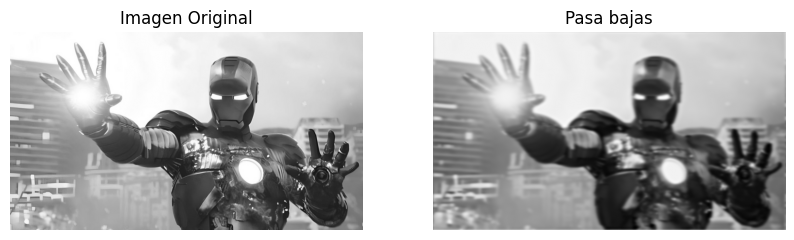

In [ ]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(I1, cmap='gray')
plt.title("Imagen Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_back, cmap='gray')
plt.title("Pasa bajas")
plt.axis("off")

plt.show()

In [ ]:
H_hp = 1 - H

In [ ]:
G_hp = fshift * H_hp

f_ishift_hp = np.fft.ifftshift(G_hp)
img_high = np.fft.ifft2(f_ishift_hp)
img_high = np.abs(img_high)

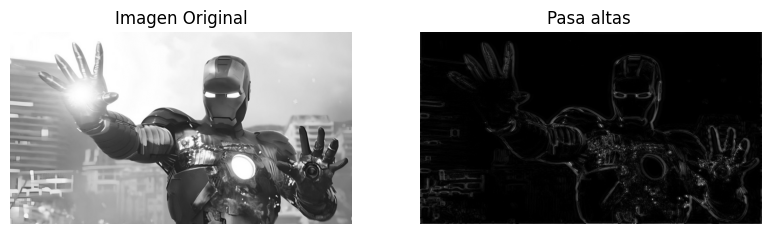

In [ ]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(I1, cmap='gray')
plt.title("Imagen Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(img_high, cmap='gray')
plt.title("Pasa altas ")
plt.axis("off")

plt.show()